# Leçon 1 & 2 — États de Bell et bases quantiques
IBM quantum Learning Use a quantum computer today

{'11': 515, '00': 485}


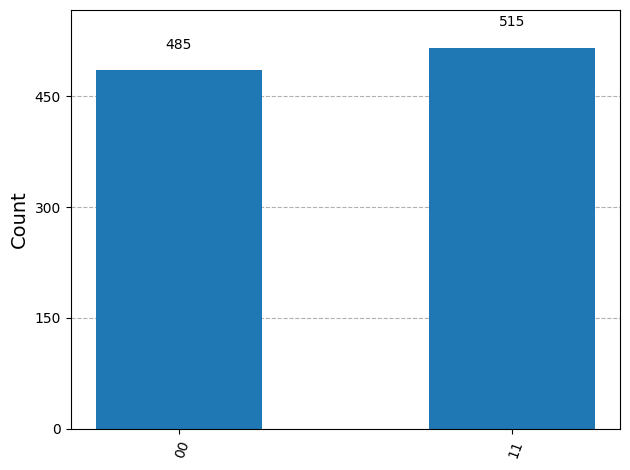

In [4]:
# État de Bell Φ+ : (|00⟩ + |11⟩) / √2
# Les deux qubits sont identiques à la mesure : soit 00, soit 11

from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2 as Sampler

# Construction du circuit
bell = QuantumCircuit(2)
bell.h(0)      # Porte Hadamard : met qubit 0 en superposition 50/50
bell.cx(0, 1)  # CNOT : entrelace les deux qubits
bell.measure_all()

# Exécution sur simulateur
backend = AerSimulator()
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuit = pm.run(bell)

sampler = Sampler(mode=backend)
job = sampler.run([isa_circuit], shots=1000)
result = job.result()
counts = result[0].data.meas.get_counts()

print(counts)
plot_histogram(counts)

{'01': 496, '10': 504}


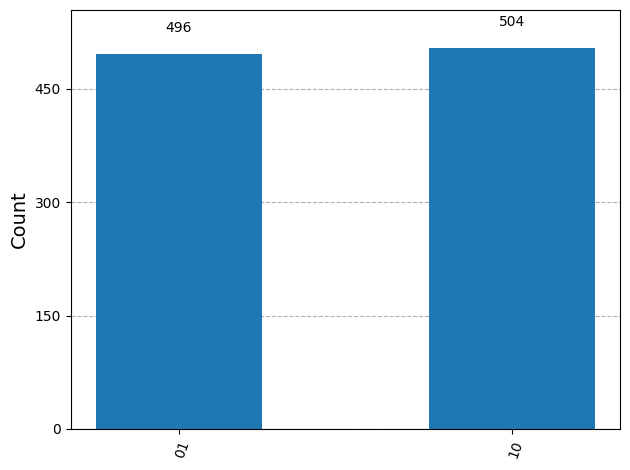

In [5]:
# État de Bell Ψ- : (|01⟩ - |10⟩) / √2
# Les deux qubits sont opposés à la mesure : soit 01, soit 10
# Différence avec Φ+ : on ajoute X sur qubit 1 (inverse les résultats)
# et Z sur qubit 0 (introduit le signe moins — invisible sur histogramme
# mais réel dans l'état quantique)

bell = QuantumCircuit(2)
bell.h(0)
bell.cx(0, 1)
bell.x(1)  # Inverse qubit 1 : transforme 00/11 en 01/10
bell.z(0)  # Introduit le signe moins dans l'amplitude
bell.measure_all()

backend = AerSimulator()
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuit = pm.run(bell)

sampler = Sampler(mode=backend)
job = sampler.run([isa_circuit], shots=1000)
result = job.result()
counts = result[0].data.meas.get_counts()

print(counts)
plot_histogram(counts)

## Concepts clés — Leçons 1 & 2

### Qubit
Unité de base de l'informatique quantique.
Démarre toujours à |0⟩ par convention (état de repos physique).
Représenté par un vecteur : |0⟩ = [1, 0] et |1⟩ = [0, 1]

### Superposition
Un qubit peut être α|0⟩ + β|1⟩ avec α² + β² = 1.
α et β sont les amplitudes — leur carré donne les probabilités.
La superposition disparaît à la mesure : le qubit choisit 0 ou 1.

### Intrication (entanglement)
Deux qubits intriqués forment un seul système — ils ne peuvent
pas être décrits indépendamment.
Mesurer l'un détermine instantanément l'état de l'autre.

### Les 4 états de Bell
| État | Formule | Résultats possibles |
|------|---------|-------------------|
| Φ+  | (|00⟩ + |11⟩) / √2 | 00 ou 11 |
| Φ−  | (|00⟩ - |11⟩) / √2 | 00 ou 11 |
| Ψ+  | (|01⟩ + |10⟩) / √2 | 01 ou 10 |
| Ψ−  | (|01⟩ - |10⟩) / √2 | 01 ou 10 |
Le signe − change la phase mais pas les probabilités de mesure.

### Portes comme matrices
Chaque porte quantique = une matrice qui transforme le vecteur d'état.
Hadamard : H = (1/√2) × [[1, 1], [1, -1]]
Réversibles, déterministes, conservent la longueur du vecteur.

### Mesure
Irréversible — détruit la superposition.
Aléatoire — probabilité = amplitude².
Différentes bases possibles : Z (standard), X, Y.

### Matrices de Pauli
X = [[0,1],[1,0]] — porte NOT, inverse |0⟩ et |1⟩
Y = [[0,-i],[i,0]] — inverse + phase
Z = [[1,0],[0,-1]] — introduit un signe moins sur |1⟩
Double rôle : portes (transforment) et observables (posent une question).